Scenario Analysis

The objective of this notebook is to evaluate how realistic business disruptions affect network performance, operating cost, and service feasibility.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pulp import (
    LpProblem,
    LpMinimize,
    LpVariable,
    lpSum,
    LpStatus,
    value
)

plant_summary = pd.read_csv(
    "../data/processed/plant_summary.csv"
)

customer_demand_scaled = pd.read_csv(
    "../data/processed/customer_demand_scaled.csv"
)

file_path = "../data/raw/Supply chain logistics problem.xlsx"

wh_capacities = pd.read_excel(
    file_path,
    sheet_name="WhCapacities"
)



In [3]:
#Setting up the notebook variables
# # Recreate optimization inputs from Notebook 04/05

plants = plant_summary['Plant ID'].tolist()

customers = customer_demand_scaled['Customer'].tolist()

capacity = dict(
    zip(
        plant_summary['Plant ID'],
        plant_summary['Daily Capacity ']
    )
)

warehouse_cost_dict = dict(
    zip(
        plant_summary['Plant ID'],
        plant_summary['Cost/unit']
    )
)

demand = dict(
    zip(
        customer_demand_scaled['Customer'],
        customer_demand_scaled['Scaled_Demand']
    )
)

from pulp import *

def solve_network_scenario(
    demand_dict,
    capacity_dict,
    cost_dict,
    scenario_name="Scenario"
):

    model = LpProblem(
        scenario_name,
        LpMinimize
    )

    x = LpVariable.dicts(
        "shipment",
        [(i, j) for i in plants for j in customers],
        lowBound=0
    )

    model += lpSum(
        cost_dict[i] * x[(i, j)]
        for i in plants
        for j in customers
    )

    for j in customers:
        model += (
            lpSum(x[(i, j)] for i in plants)
            >= demand_dict[j]
        )

    for i in plants:
        model += (
            lpSum(x[(i, j)] for j in customers)
            <= capacity_dict[i]
        )

    model.solve()

    return {
        "Scenario": scenario_name,
        "Status": LpStatus[model.status],
        "Cost": value(model.objective)
    }


In [9]:
baseline_result = solve_network_scenario(
    demand,
    capacity,
    warehouse_cost_dict,
    "Baseline"
)

baseline_result

{'Scenario': 'Baseline', 'Status': 'Optimal', 'Cost': 3300.7480749470974}

In [4]:
# Increase demand by 15%

peak_demand = {
    k: v * 1.15
    for k, v in demand.items()
}

scenario_a = solve_network_scenario(
    peak_demand,
    capacity,
    warehouse_cost_dict,
    "Peak Season (+15%)"
)

scenario_a

f:\Projects\transport-network-optimization\.venv\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


{'Scenario': 'Peak Season (+15%)',
 'Status': 'Infeasible',
 'Cost': 4449.241754732439}

In [5]:
# Increase all plant capacities by 10%

capacity_expanded = {
    k: v * 1.10
    for k, v in capacity.items()
}

scenario_b = solve_network_scenario(
    demand,
    capacity_expanded,
    warehouse_cost_dict,
    "Capacity Expansion (+10%)"
)

scenario_b

{'Scenario': 'Capacity Expansion (+10%)',
 'Status': 'Optimal',
 'Cost': 2846.746629626045}

In [6]:
capacity_c = capacity.copy()

capacity_c['PLANT01'] *= 0.75
capacity_c['PLANT03'] *= 0.75

scenario_c = solve_network_scenario(
    demand,
    capacity_c,
    warehouse_cost_dict,
    "Dual Plant Disruption"
)

scenario_c

{'Scenario': 'Dual Plant Disruption',
 'Status': 'Infeasible',
 'Cost': 3845.6224512389663}

In [7]:
capacity_d = capacity.copy()

capacity_d['PLANT04'] = 0

scenario_d = solve_network_scenario(
    demand,
    capacity_d,
    warehouse_cost_dict,
    "PLANT04 Outage"
)

scenario_d

{'Scenario': 'PLANT04 Outage',
 'Status': 'Infeasible',
 'Cost': 3884.7101784705337}

In [10]:
scenario_results = pd.DataFrame([
    baseline_result,
    scenario_a,
    scenario_b,
    scenario_c,
    scenario_d
])

scenario_results

,Scenario,Status,Cost
0,Baseline,Optimal,3300.748075
1,Peak Season (+15%),Infeasible,4449.241755
2,Capacity Expansion (+10%),Optimal,2846.746630
3,Dual Plant Disruption,Infeasible,3845.622451
4,PLANT04 Outage,Infeasible,3884.710178


In [11]:
# Baseline network capacity

baseline_capacity = sum(capacity.values())

print("Daily Capacity:", baseline_capacity)

Daily Capacity: 5791


In [12]:
#Creating the Simultaion function

def simulate_backlog(
    daily_demand,
    daily_capacity,
    disruption_days,
    outage_capacity_loss,
    emergency_capacity_pct=0.10,
    simulation_days=30
):

    backlog = 0

    results = []

    for day in range(1, simulation_days + 1):

        # Outage period
        if day <= disruption_days:

            available_capacity = (
                daily_capacity
                - outage_capacity_loss
            )

            available_capacity *= (
                1 + emergency_capacity_pct
            )

        # Recovery period
        else:

            available_capacity = (
                daily_capacity
                * (1 + emergency_capacity_pct)
            )

        workload = daily_demand + backlog

        processed = min(
            workload,
            available_capacity
        )

        backlog = workload - processed

        results.append([
            day,
            workload,
            available_capacity,
            processed,
            backlog
        ])

    return pd.DataFrame(
        results,
        columns=[
            "Day",
            "Workload",
            "Available Capacity",
            "Processed",
            "Backlog"
        ]
    )

In [19]:
plant_capacity = wh_capacities.copy()

plant_capacity.loc[
    plant_capacity['Plant ID'] == 'PLANT03'
]

,Plant ID,Daily Capacity
14,PLANT03,1013


In [21]:
plant03_capacity = 1013

In [22]:
backlog_sim = simulate_backlog(
    daily_demand=sum(demand.values()),
    daily_capacity=sum(capacity.values()),
    disruption_days=3,
    outage_capacity_loss=plant03_capacity,
    emergency_capacity_pct=0.10,
    simulation_days=30
)

backlog_sim.head(10)

,Day,Workload,Available Capacity,Processed,Backlog
0,1,5501.45,5255.8,5255.80,245.65
1,2,5747.10,5255.8,5255.80,491.30
2,3,5992.75,5255.8,5255.80,736.95
3,4,6238.40,6370.1,6238.40,0.00
4,5,5501.45,6370.1,5501.45,0.00
5,6,5501.45,6370.1,5501.45,0.00
6,7,5501.45,6370.1,5501.45,0.00
7,8,5501.45,6370.1,5501.45,0.00
8,9,5501.45,6370.1,5501.45,0.00
9,10,5501.45,6370.1,5501.45,0.00


In [23]:
peak_backlog = backlog_sim['Backlog'].max()

recovery_day = backlog_sim.loc[
    backlog_sim['Backlog'] == 0,
    'Day'
].min()

print("Peak Backlog:", round(peak_backlog,2))
print("Recovery Day:", recovery_day)

Peak Backlog: 736.95
Recovery Day: 4


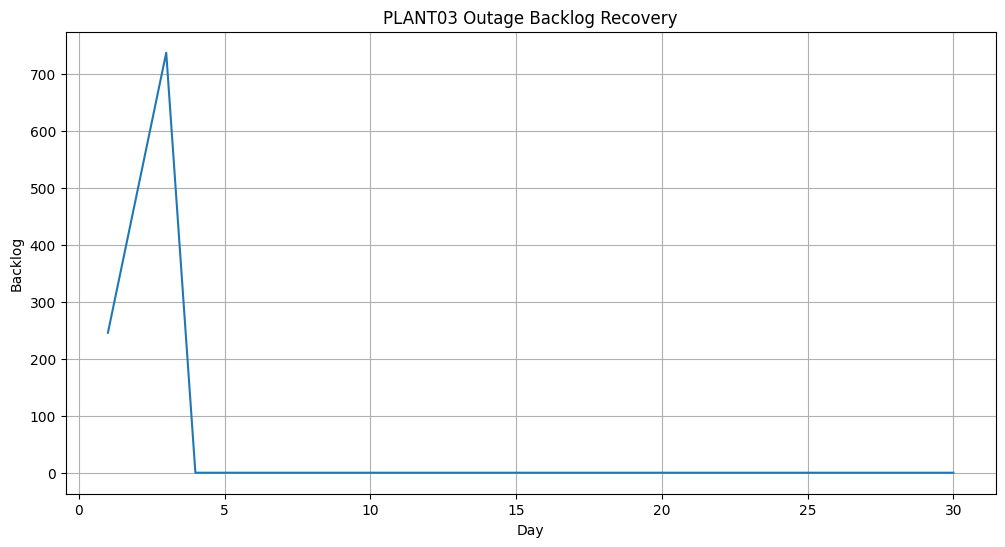

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    backlog_sim['Day'],
    backlog_sim['Backlog']
)

plt.title(
    'PLANT03 Outage Backlog Recovery'
)

plt.xlabel('Day')
plt.ylabel('Backlog')

plt.grid(True)

plt.show()

In [35]:
# Peak season demand surge

peak_demand = sum(demand.values()) * 1.25

baseline_capacity = sum(capacity.values())

print("Peak Demand:", round(peak_demand, 2))
print("Capacity:", baseline_capacity)

Peak Demand: 6876.81
Capacity: 5791


In [36]:
def simulate_demand_surge(
    daily_demand,
    daily_capacity,
    surge_days=7,
    emergency_capacity_pct=0.10,
    simulation_days=30
):

    backlog = 0
    results = []

    for day in range(1, simulation_days + 1):

        # Peak season active
        if day <= surge_days:

            demand_today = daily_demand

        # Return to normal demand
        else:

            demand_today = sum(demand.values())

        available_capacity = (
            daily_capacity
            * (1 + emergency_capacity_pct)
        )

        workload = demand_today + backlog

        processed = min(
            workload,
            available_capacity
        )

        backlog = workload - processed

        results.append([
            day,
            demand_today,
            available_capacity,
            processed,
            backlog
        ])

    return pd.DataFrame(
        results,
        columns=[
            "Day",
            "Demand",
            "Capacity",
            "Processed",
            "Backlog"
        ]
    )

In [37]:
surge_sim = simulate_demand_surge(
    daily_demand=peak_demand,
    daily_capacity=sum(capacity.values()),
    surge_days=7,
    emergency_capacity_pct=0.10,
    simulation_days=30
)

surge_sim.head(15)

,Day,Demand,Capacity,Processed,Backlog
0,1,6876.8125,6370.1,6370.1000,506.7125
1,2,6876.8125,6370.1,6370.1000,1013.4250
2,3,6876.8125,6370.1,6370.1000,1520.1375
3,4,6876.8125,6370.1,6370.1000,2026.8500
4,5,6876.8125,6370.1,6370.1000,2533.5625
5,6,6876.8125,6370.1,6370.1000,3040.2750
6,7,6876.8125,6370.1,6370.1000,3546.9875
7,8,5501.4500,6370.1,6370.1000,2678.3375
8,9,5501.4500,6370.1,6370.1000,1809.6875
9,10,5501.4500,6370.1,6370.1000,941.0375


In [41]:
peak_backlog = surge_sim['Backlog'].max()

final_backlog = surge_sim['Backlog'].iloc[-1]

recovery_day = surge_sim.loc[
    surge_sim['Backlog'] == 0,
    'Day'
].min()

print("Peak Backlog:", round(peak_backlog,2))
print("Recovery Day:", recovery_day)
print("Final Backlog:", round(final_backlog,2))

Peak Backlog: 3546.99
Recovery Day: 12
Final Backlog: 0.0


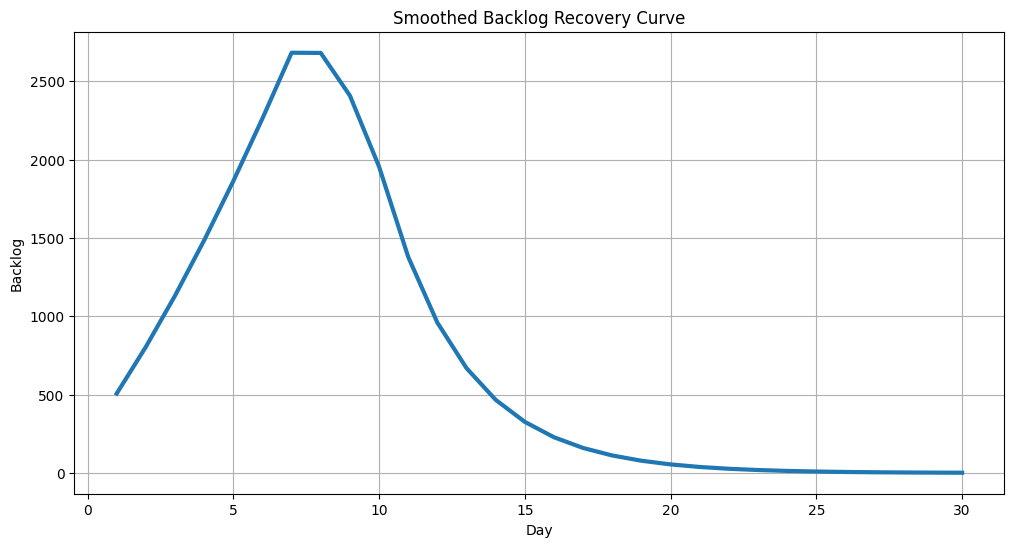

In [42]:
surge_sim['Backlog_Exp'] = (
    surge_sim['Backlog']
    .ewm(alpha=0.3)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    surge_sim['Day'],
    surge_sim['Backlog_Exp'],
    linewidth=3
)

plt.title('Smoothed Backlog Recovery Curve')
plt.xlabel('Day')
plt.ylabel('Backlog')
plt.grid(True)

plt.show()

In [47]:
# Demand Surge Metrics

peak_backlog_surge = surge_sim['Backlog'].max()

recovery_day_surge = surge_sim.loc[
    surge_sim['Backlog'] == 0,
    'Day'
].min()

print("Peak Backlog Surge:", peak_backlog_surge)
print("Recovery Day Surge:", recovery_day_surge)

Peak Backlog Surge: 3546.9874999999975
Recovery Day Surge: 12


In [49]:
# PLANT03 Outage Metrics

peak_backlog_outage = backlog_sim['Backlog'].max()

recovery_day_outage = backlog_sim.loc[
    backlog_sim['Backlog'] == 0,
    'Day'
].min()

print("Peak Backlog Outage:", peak_backlog_outage)
print("Recovery Day Outage:", recovery_day_outage)

Peak Backlog Outage: 736.9499999999989
Recovery Day Outage: 4


In [50]:
scenario_summary = pd.DataFrame({
    'Scenario': [
        'Baseline',
        'Demand Surge',
        'PLANT03 Outage'
    ],
    'Peak Backlog': [
        0,
        peak_backlog_surge,
        peak_backlog_outage
    ],
    'Recovery Day': [
        0,
        recovery_day_surge,
        recovery_day_outage
    ]
})

scenario_summary

,Scenario,Peak Backlog,Recovery Day
0,Baseline,0.0000,0
1,Demand Surge,3546.9875,12
2,PLANT03 Outage,736.9500,4


In [53]:
print("Demand Surge")
print("Peak Backlog:", peak_backlog_surge)
print("Recovery Day:", recovery_day_surge)

print("\nPLANT03 Outage")
print("Peak Backlog:", peak_backlog_outage)
print("Recovery Day:", recovery_day_outage)

Demand Surge
Peak Backlog: 3546.9874999999975
Recovery Day: 12

PLANT03 Outage
Peak Backlog: 736.9499999999989
Recovery Day: 4


In [54]:
scenario_summary

,Scenario,Peak Backlog,Recovery Day
0,Baseline,0.0000,0
1,Demand Surge,3546.9875,12
2,PLANT03 Outage,736.9500,4


## Scenario Analysis Findings

### Demand Surge Scenario
A 20% peak-season demand increase generated a peak backlog of 3,546.99 units and required 12 days to fully recover.
The backlog accumulated because demand exceeded available processing capacity during the surge period. Although emergency capacity measures were implemented, the network required nearly two weeks to eliminate the accumulated workload.

### PLANT03 Outage Scenario
A temporary outage at PLANT03 generated a peak backlog of 736.95 units and required 4 days to recover.
PLANT03 is one of the largest production facilities in the network, and its temporary loss significantly reduced available capacity. However, emergency capacity expansion at remaining facilities enabled relatively rapid recovery.
